In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from datasets import load_dataset

df = load_dataset("stanfordnlp/imdb")

C:\Users\tg_mu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [4]:
df['train']

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [5]:
train=pd.DataFrame(data=df['train'])
train

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
...,...,...
24995,A hit at the time but now better categorised a...,1
24996,I love this movie like no other. Another time ...,1
24997,This film and it's sequel Barry Mckenzie holds...,1
24998,'The Adventures Of Barry McKenzie' started lif...,1


In [6]:
test=pd.DataFrame(data=df['test'])
test

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0
...,...,...
24995,Just got around to seeing Monster Man yesterda...,1
24996,I got this as part of a competition prize. I w...,1
24997,I got Monster Man in a box set of three films ...,1
24998,"Five minutes in, i started to feel how naff th...",1


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


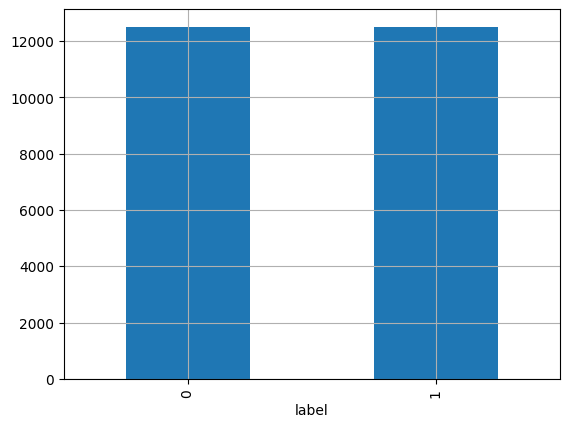

In [8]:
train['label'].value_counts().plot.bar()
plt.grid()
plt.show()

In [9]:
text=train['text']
text

0        I rented I AM CURIOUS-YELLOW from my video sto...
1        "I Am Curious: Yellow" is a risible and preten...
2        If only to avoid making this type of film in t...
3        This film was probably inspired by Godard's Ma...
4        Oh, brother...after hearing about this ridicul...
                               ...                        
24995    A hit at the time but now better categorised a...
24996    I love this movie like no other. Another time ...
24997    This film and it's sequel Barry Mckenzie holds...
24998    'The Adventures Of Barry McKenzie' started lif...
24999    The story centers around Barry McKenzie who mu...
Name: text, Length: 25000, dtype: object

In [10]:
lengths=[len(text[i]) for i in range(len(text))]
lengths

[1640,
 1294,
 528,
 706,
 1814,
 661,
 637,
 1698,
 2812,
 1265,
 1502,
 723,
 784,
 697,
 2009,
 1140,
 464,
 5145,
 356,
 914,
 967,
 893,
 937,
 1889,
 579,
 980,
 1317,
 572,
 1277,
 1988,
 826,
 802,
 852,
 1124,
 2152,
 637,
 758,
 1542,
 1201,
 632,
 682,
 718,
 4714,
 1170,
 2794,
 786,
 660,
 629,
 802,
 687,
 1115,
 1155,
 2645,
 1351,
 1545,
 2714,
 1518,
 767,
 701,
 247,
 1172,
 1015,
 862,
 1878,
 693,
 1922,
 1546,
 701,
 434,
 4271,
 1260,
 330,
 807,
 650,
 2237,
 655,
 924,
 1054,
 701,
 1829,
 3584,
 708,
 1930,
 900,
 1454,
 1562,
 1441,
 2955,
 1539,
 1849,
 1455,
 694,
 4766,
 288,
 616,
 2980,
 1014,
 794,
 2969,
 737,
 822,
 914,
 1375,
 1270,
 965,
 1516,
 1269,
 754,
 1046,
 912,
 266,
 2421,
 2818,
 996,
 693,
 1928,
 761,
 739,
 746,
 824,
 1757,
 720,
 1017,
 451,
 1823,
 748,
 718,
 655,
 4815,
 1629,
 1647,
 705,
 1246,
 662,
 836,
 409,
 1386,
 1272,
 1049,
 280,
 815,
 1282,
 3413,
 898,
 911,
 675,
 631,
 2535,
 772,
 2119,
 956,
 752,
 864,
 1091,
 9

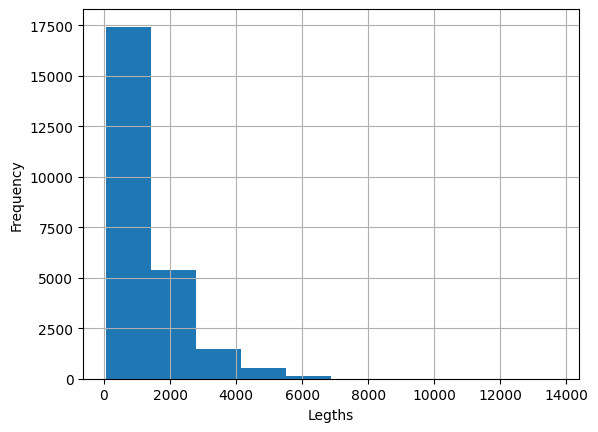

In [11]:
pd.Series(lengths).hist()
plt.xlabel('Legths')
plt.ylabel('Frequency')
plt.show()

In [12]:
max(lengths)

13704

In [13]:
min(lengths)

52

In [14]:
#def remove_stopwords(text):
    #stop_words=set(stopwords.words('english'))
    #filtered=[word for word in text.split() if word.lower() not in stop_words]
    #return filtered

In [15]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words=stopwords.words('english')

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words=stop_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tg_mu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
output=tfidf.fit_transform(text)
output

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2479678 stored elements and shape (25000, 74704)>

In [17]:
output=output.toarray()
output

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(25000, 74704))

In [18]:
tfidf.get_feature_names_out()

array(['00', '000', '0000000000001', ..., 'østbye', 'über', 'üvegtigris'],
      shape=(74704,), dtype=object)

In [19]:
output=pd.DataFrame(output,columns=tfidf.get_feature_names_out())
output

,00,000,0000000000001,00001,00015,000s,001,003830,006,007,...,était,état,étc,évery,êxtase,ís,ísnt,østbye,über,üvegtigris
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
train['label']

0        0
1        0
2        0
3        0
4        0
        ..
24995    1
24996    1
24997    1
24998    1
24999    1
Name: label, Length: 25000, dtype: int64

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(output,train['label'],test_size=0.2,random_state=42)

In [22]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(20000, 74704)
(5000, 74704)
(20000,)
(5000,)


In [23]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression()

In [24]:
lr_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
y_pred_lr=lr_model.predict(X_test)

In [26]:
from sklearn.metrics import classification_report,confusion_matrix

In [27]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      2515
           1       0.88      0.90      0.89      2485

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



In [28]:
print(confusion_matrix(y_test,y_pred_lr))

[[2209  306]
 [ 240 2245]]
